In [1]:

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Task 1: Dataset Understanding

In [2]:
df = pd.read_csv(r'C:\Users\ayubi\Downloads\ai_project_synthetic_datasets-20260513T191430Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv')

print('=== DATASET OVERVIEW ===')
print(f'Number of records : {len(df)}')
print(f'Number of features: {df.shape[1]}')
print(f'Columns           : {df.columns.tolist()}')
print(f'Missing values    : {df.isnull().sum().sum()}')
print()
print('=== TARGET CLASSES ===')
print(df["sentiment_label"].value_counts())
print()
print(f'Average message length (chars): {df["customer_message"].str.len().mean():.1f}')
print(f'Average word count            : {df["word_count"].mean():.1f}')

=== DATASET OVERVIEW ===
Number of records : 1500
Number of features: 6
Columns           : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']
Missing values    : 0

=== TARGET CLASSES ===
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average message length (chars): 72.8
Average word count            : 12.7


In [3]:
print('=== SAMPLE RECORDS BY CLASS ===')
for label in ['positive', 'negative', 'neutral']:
    msg = df[df['sentiment_label']==label]['customer_message'].iloc[0]
    print(f'[{label.upper()}]\n  {msg}\n')

=== SAMPLE RECORDS BY CLASS ===
[POSITIVE]
  The refund process was fast and convenient. I appreciate the quick response.

[NEGATIVE]
  My refund is still pending and this experience is frustrating. My ticket number is 33927.

[NEUTRAL]
  I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.



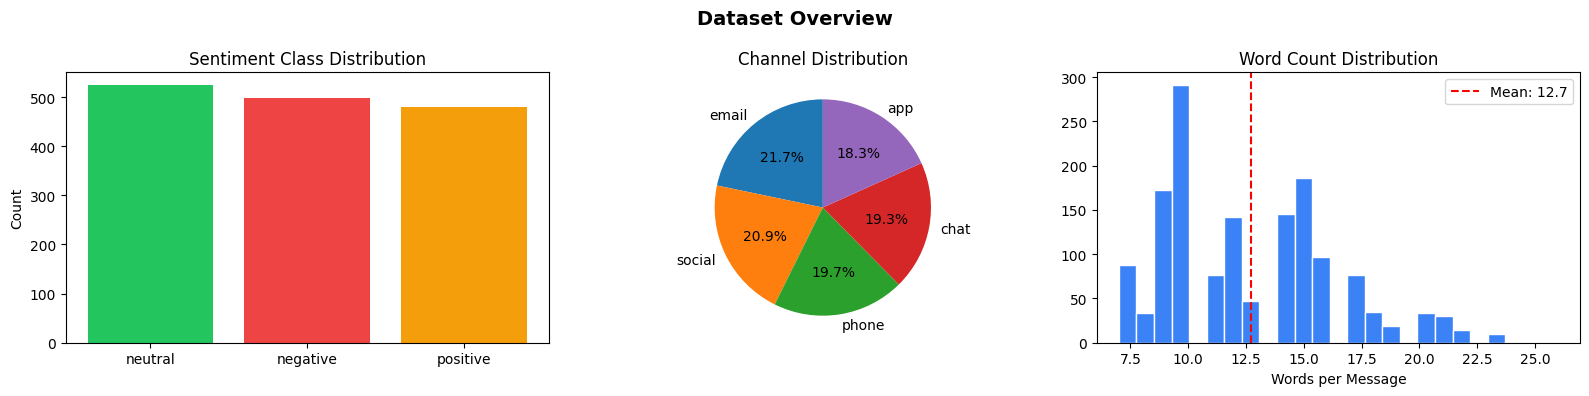

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Class distribution
counts = df['sentiment_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#22c55e','#ef4444','#f59e0b'])
axes[0].set_title('Sentiment Class Distribution')
axes[0].set_ylabel('Count')

# Channel distribution
ch = df['channel'].value_counts()
axes[1].pie(ch.values, labels=ch.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Channel Distribution')

# Word count distribution
axes[2].hist(df['word_count'], bins=25, color='#3b82f6', edgecolor='white')
axes[2].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Words per Message')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2: Text Preprocessing

In [5]:
# Manual stopwords (no NLTK download dependency)
STOPWORDS = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves','what','which','who',
    'whom','this','that','these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','a','an','the','and','but','if',
    'or','because','as','until','while','of','at','by','for','with','about','against',
    'between','into','through','during','before','after','above','below','to','from',
    'up','down','in','out','on','off','over','under','again','further','then','once',
    'here','there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than','too','very',
    's','t','can','will','just','don','should','now','d','ll','m','o','re','ve','y',
    'ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma','mightn',
    'mustn','needn','shan','shouldn','wasn','weren','won','wouldn'])

def preprocess_text(text):
    """Full text preprocessing pipeline."""
    if pd.isna(text): return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize (whitespace split)
    tokens = text.split()
    # 4. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['customer_message'].apply(preprocess_text)

print('Preprocessing pipeline: lowercase → strip special chars → tokenize → remove stopwords')
print()
print('Before:', df['customer_message'].iloc[0])
print('After :', df['clean_text'].iloc[0])
print()
print(f'Avg tokens before: {df["word_count"].mean():.1f}')
print(f'Avg tokens after : {df["clean_text"].str.split().str.len().mean():.1f}')

Preprocessing pipeline: lowercase → strip special chars → tokenize → remove stopwords

Before: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
After : need information payment process ticket number please respond soon possible

Avg tokens before: 12.7
Avg tokens after : 6.7


## Task 3: Text Vectorization

**Why must text be converted to vectors?**

Machine learning models are mathematical functions — they compute gradients, dot products, and matrix multiplications. These operations require *numerical* inputs. Raw text is a sequence of characters; it has no natural numeric representation a model can directly operate on.

Vectorization creates a fixed-size numerical representation of each document:
- **Bag of Words (BoW):** counts how often each vocabulary word appears, ignoring order.
- **TF-IDF:** weights each word by how important it is (frequent in this doc, rare across corpus).
- **Word Embeddings:** learn a dense, semantic vector per word (e.g. `king - man + woman ≈ queen`).
- **Tokenizer-based sequences:** preserve word order — essential for sequence models like LSTMs.

In [6]:
# Bag of Words
bow_vec = CountVectorizer(max_features=5000)
X_bow = bow_vec.fit_transform(df['clean_text'])
print(f'Bag-of-Words shape : {X_bow.shape}  (samples × vocab_size)')
print(f'Sample BoW features: {bow_vec.get_feature_names_out()[:15].tolist()}')
print()

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df['clean_text'])
print(f'TF-IDF shape       : {X_tfidf.shape}  (samples × vocab_size, with bigrams)')
print(f'Sample TF-IDF feats: {tfidf_vec.get_feature_names_out()[:15].tolist()}')

Bag-of-Words shape : (1500, 147)  (samples × vocab_size)
Sample BoW features: ['account', 'activate', 'ago', 'analytics', 'any', 'app', 'appreciate', 'arrived', 'assigned', 'available', 'bad', 'billing', 'call', 'cancel', 'care']

TF-IDF shape       : (1500, 431)  (samples × vocab_size, with bigrams)
Sample TF-IDF feats: ['account', 'account details', 'account keeps', 'account request', 'account worked', 'account working', 'activate', 'activate analytics', 'activate login', 'activate notifications', 'activate payment', 'activate profile', 'activate report', 'activate tracking', 'activate video']


## Task 4: Baseline Models

In [7]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment_label'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(y_train)} | Test: {len(y_test)}')

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 1200 | Test: 300


In [8]:
# Model 1: Logistic Regression + TF-IDF
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print('--- Logistic Regression (TF-IDF) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

--- Logistic Regression (TF-IDF) ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [9]:
# Model 2: Naïve Bayes + BoW
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_bow, y_train)
y_pred_nb = nb_model.predict(X_test_bow)

print('--- Naïve Bayes (Bag of Words) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

--- Naïve Bayes (Bag of Words) ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



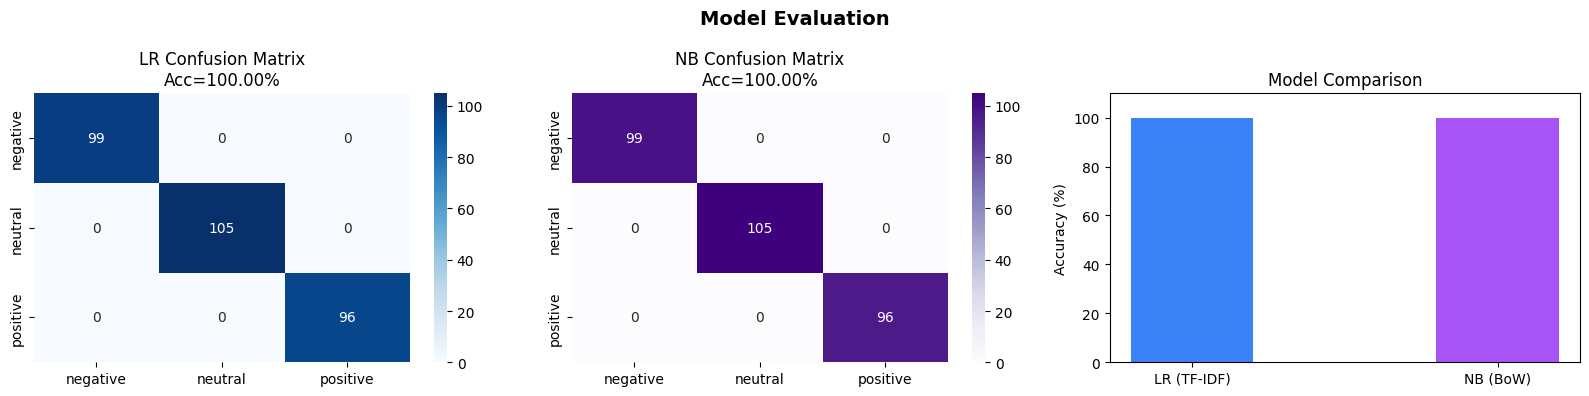

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'LR Confusion Matrix\nAcc={accuracy_score(y_test,y_pred_lr):.2%}')

# Confusion matrix NB
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', ax=axes[1], cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'NB Confusion Matrix\nAcc={accuracy_score(y_test,y_pred_nb):.2%}')

# Accuracy bar
axes[2].bar(['LR (TF-IDF)', 'NB (BoW)'],
            [accuracy_score(y_test,y_pred_lr)*100, accuracy_score(y_test,y_pred_nb)*100],
            color=['#3b82f6','#a855f7'], width=0.4)
axes[2].set_ylim(0, 110)
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Model Comparison')

plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 5: Sequence Model — LSTM Architecture

When full training is not feasible, we define the architecture and explain the data flow.

In [11]:
# LSTM Architecture (Keras/TensorFlow)
VOCAB_SIZE   = 10000  # top N words
MAX_SEQ_LEN  = 50     # pad/truncate to 50 tokens
EMBED_DIM    = 128    # embedding vector size
LSTM_UNITS   = 64
NUM_CLASSES  = 3      # negative, neutral, positive

ARCHITECTURE = '''
Model: "sentiment_lstm"
_____________________________________________________________
Layer (type)            Output Shape          Param #
=============================================================
Input (InputLayer)      [(None, 50)]          0
Embedding               (None, 50, 128)       1,280,000
SpatialDropout1D(0.2)   (None, 50, 128)       0
LSTM(64, dropout=0.3)   (None, 64)            49,408
Dense(32, relu)         (None, 32)            2,080
Dropout(0.3)            (None, 32)            0
Dense(3, softmax)       (None, 3)             99
=============================================================
Total params: 1,331,587
Trainable params: 1,331,587
'''
print(ARCHITECTURE)

print('Processing steps:')
print('  1. Input sequence  — integer token IDs, padded to 50 tokens')
print('  2. Embedding layer — maps each token ID to a 128-dim dense vector (learned)')
print('  3. LSTM layer      — processes token sequence, maintains hidden state across 50 steps')
print('  4. Dense (ReLU)    — non-linear feature combination')
print('  5. Output (Softmax)— probabilities for [negative, neutral, positive]')
print()
print('Loss function   : categorical_crossentropy')
print('Optimizer       : Adam (lr=1e-3)')
print('Evaluation metric: accuracy, F1-score (macro)')


Model: "sentiment_lstm"
_____________________________________________________________
Layer (type)            Output Shape          Param #
Input (InputLayer)      [(None, 50)]          0
Embedding               (None, 50, 128)       1,280,000
SpatialDropout1D(0.2)   (None, 50, 128)       0
LSTM(64, dropout=0.3)   (None, 64)            49,408
Dense(32, relu)         (None, 32)            2,080
Dropout(0.3)            (None, 32)            0
Dense(3, softmax)       (None, 3)             99
Total params: 1,331,587
Trainable params: 1,331,587

Processing steps:
  1. Input sequence  — integer token IDs, padded to 50 tokens
  2. Embedding layer — maps each token ID to a 128-dim dense vector (learned)
  3. LSTM layer      — processes token sequence, maintains hidden state across 50 steps
  4. Dense (ReLU)    — non-linear feature combination
  5. Output (Softmax)— probabilities for [negative, neutral, positive]

Loss function   : categorical_crossentropy
Optimizer       : Adam (lr=1e-3)
Eval

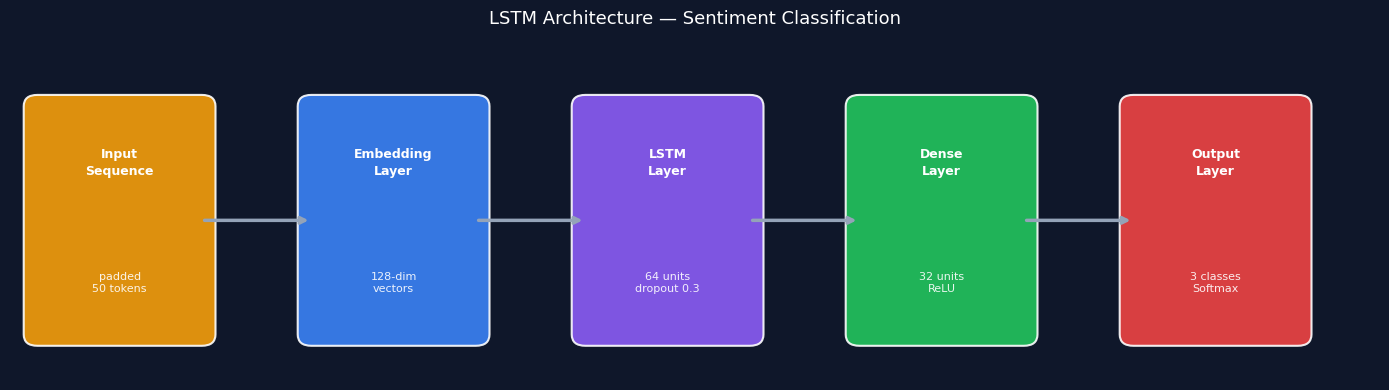

In [12]:
# LSTM Architecture Diagram
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 10); ax.set_ylim(0, 3)
ax.axis('off')
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0f172a')
ax.set_title('LSTM Architecture — Sentiment Classification', color='white', fontsize=13, pad=10)

layers = [
    (0.8, '#f59e0b', 'Input\nSequence', 'padded\n50 tokens'),
    (2.8, '#3b82f6', 'Embedding\nLayer', '128-dim\nvectors'),
    (4.8, '#8b5cf6', 'LSTM\nLayer', '64 units\ndropout 0.3'),
    (6.8, '#22c55e', 'Dense\nLayer', '32 units\nReLU'),
    (8.8, '#ef4444', 'Output\nLayer', '3 classes\nSoftmax'),
]
for x, color, title, sub in layers:
    rect = mpatches.FancyBboxPatch((x-0.6, 0.4), 1.2, 2.0,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='white', alpha=0.9, lw=1.5)
    ax.add_patch(rect)
    ax.text(x, 1.9, title, ha='center', va='center', color='white',
            fontsize=9, fontweight='bold', linespacing=1.4)
    ax.text(x, 0.85, sub, ha='center', va='center', color='white',
            fontsize=8, linespacing=1.3, alpha=0.9)

for i in range(len(layers)-1):
    x1 = layers[i][0]+0.6; x2 = layers[i+1][0]-0.6
    ax.annotate('', xy=(x2, 1.4), xytext=(x1, 1.4),
                arrowprops=dict(arrowstyle='->', color='#94a3b8', lw=2.5))

plt.tight_layout()
plt.savefig('results/lstm_architecture.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## Task 6: Attention and Transformer Reflection

### Why do RNNs struggle with long-term dependencies?
RNNs pass information as a single hidden state vector from one step to the next. With long sequences (e.g. 200+ tokens), the gradient of the loss with respect to early tokens vanishes exponentially as it propagates back through many timesteps — the **vanishing gradient problem**. The network effectively forgets early context.

### How do LSTMs help with memory?
LSTMs introduce a **cell state** — a separate memory highway that runs alongside the hidden state. Three trainable gates (`input`, `forget`, `output`) learn *when* to write to memory, *what* to erase, and *what* to expose to the next layer. This lets the model retain relevant context across hundreds of timesteps without the gradient disappearing.

### What does attention solve in seq-to-seq tasks?
Encoder-decoder RNNs compress the entire input into a fixed-size context vector, losing detail for long inputs. **Attention** lets the decoder query the full set of encoder hidden states at each decoding step — essentially a weighted soft-lookup — so it can focus on the most relevant input positions for each output word. This dramatically improves translation quality for long sentences.

### Why are Transformers important in modern NLP and Generative AI?
Transformers replace sequential recurrence entirely with **self-attention**: every token attends to every other token in parallel. Benefits:
- **No sequential bottleneck** → hardware-friendly parallelism → can train on massive corpora.
- **Scales gracefully** → stacking more layers + more heads consistently improves performance.
- **Bidirectional context by default** (BERT) or causal masking for generation (GPT).
- **Foundation models** (GPT-4, Claude, Gemini) are transformer-based and demonstrate emergent capabilities: reasoning, summarization, code generation, and multimodal understanding — all from a shared pre-trained backbone fine-tuned per task.

In [ ]:
# Save sample predictions
with open('results/sample_predictions.txt', 'w') as f:
    f.write('SAMPLE PREDICTIONS\n' + '='*60 + '\n\n')
    f.write(f'{"#":<4} {"True":<10} {"LR":<10} {"NB":<10} Text\n')
    f.write('-'*60 + '\n')
    for i in range(15):
        true = le.inverse_transform([y_test[i]])[0]
        lr_p = le.inverse_transform([y_pred_lr[i]])[0]
        nb_p = le.inverse_transform([y_pred_nb[i]])[0]
        mark = '✓' if lr_p==true else '✗'
        text = df['customer_message'].values[i][:50]
        with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
            f.write('SAMPLE PREDICTIONS\n' + '='*60 + '\n\n')
            f.write(f'{"#":<4} {"True":<10} {"LR":<10} {"NB":<10} Text\n')
            f.write('-'*60 + '\n')
            for i in range(15):
                true = le.inverse_transform([y_test[i]])[0]
                lr_p = le.inverse_transform([y_pred_lr[i]])[0]
                nb_p = le.inverse_transform([y_pred_nb[i]])[0]
                mark = '✓' if lr_p==true else '✗'
                text = df['customer_message'].values[i][:50]
                f.write(f'{mark:<4} {true:<10} {lr_p:<10} {nb_p:<10} {text}\n')
            f.write(f'\nLR Accuracy : {accuracy_score(y_test,y_pred_lr)*100:.2f}%\n')
            f.write(f'NB Accuracy : {accuracy_score(y_test,y_pred_nb)*100:.2f}%\n')
    with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
        f.write('SAMPLE PREDICTIONS\n' + '='*60 + '\n\n')
        f.write(f'{"#":<4} {"True":<10} {"LR":<10} {"NB":<10} Text\n')
        f.write('-'*60 + '\n')
        for i in range(15):
            true = le.inverse_transform([y_test[i]])[0]
            lr_p = le.inverse_transform([y_pred_lr[i]])[0]
            nb_p = le.inverse_transform([y_pred_nb[i]])[0]
            mark = '✓' if lr_p == true else '✗'
            text = df['customer_message'].values[i][:50]
            f.write(f'{mark:<4} {true:<10} {lr_p:<10} {nb_p:<10} {text}\n')
        f.write(f'\nLR Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%\n')
        f.write(f'NB Accuracy : {accuracy_score(y_test, y_pred_nb)*100:.2f}%\n')

    print('Results saved to results/')
    f.write(f'NB Accuracy : {accuracy_score(y_test,y_pred_nb)*100:.2f}%\n')

print('Results saved to results/')

ValueError: I/O operation on closed file.